# Data Analytics Project: Unemployment Rate in India by Educational Qualification

**Objective:** Analyze how India's unemployment rate varies by education level, gender, and region (2017-18 to 2023-24), based on patterns reported in the Periodic Labour Force Survey (PLFS), MoSPI, Government of India.

> **Note:** The dataset used here is constructed to closely follow publicly documented PLFS patterns (overall UR trend, COVID-19 spike in 2020-21, the well known rise in UR with education level). Exact category-wise figures should be verified against official MoSPI PLFS tables (mospi.gov.in) before use in a formal academic submission.


## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
%matplotlib inline


## 2. Build / Load the Dataset

In [8]:
np.random.seed(42)

years = ["2017-18", "2018-19", "2019-20", "2020-21", "2021-22", "2022-23", "2023-24"]

education_levels = [
    "Not Literate", "Up to Primary", "Secondary",
    "Higher Secondary", "Diploma / Certificate", "Graduate & Above",
]

base_2017_18 = {"Not Literate": 1.2, "Up to Primary": 2.1, "Secondary": 6.8,
                "Higher Secondary": 11.4, "Diploma / Certificate": 14.9, "Graduate & Above": 18.0}
base_2023_24 = {"Not Literate": 0.4, "Up to Primary": 1.1, "Secondary": 3.9,
                "Higher Secondary": 7.2, "Diploma / Certificate": 10.1, "Graduate & Above": 13.4}

year_shape = {"2017-18": 1.00, "2018-19": 0.93, "2019-20": 0.88, "2020-21": 1.15,
              "2021-22": 0.97, "2022-23": 0.85, "2023-24": 0.74}

regions = ["Rural", "Urban"]
region_multiplier = {"Rural": 0.85, "Urban": 1.25}
genders = ["Male", "Female"]
gender_multiplier = {"Male": 0.92, "Female": 1.18}

rows = []
for edu in education_levels:
    lo, hi = base_2017_18[edu], base_2023_24[edu]
    for i, yr in enumerate(years):
        t = i / (len(years) - 1)
        val_national = (lo + (hi - lo) * t) * year_shape[yr]
        for region in regions:
            for gender in genders:
                val = val_national * region_multiplier[region] * gender_multiplier[gender]
                val = val * np.random.uniform(0.95, 1.05)
                rows.append({"Year": yr, "Education_Level": edu, "Region": region,
                             "Gender": gender, "Unemployment_Rate_Percent": round(val, 1)})

df = pd.DataFrame(rows)

agg = df.groupby(["Year", "Education_Level"])["Unemployment_Rate_Percent"].mean().round(1).reset_index()
agg["Region"] = "Total"
agg["Gender"] = "Person"
agg = agg[["Year", "Education_Level", "Region", "Gender", "Unemployment_Rate_Percent"]]

df = pd.concat([df, agg], ignore_index=True).sort_values(
    ["Year", "Education_Level", "Region", "Gender"]).reset_index(drop=True)

df.to_csv("india_unemployment_by_education.csv", index=False)
df.head(10)


,Year,Education_Level,Region,Gender,Unemployment_Rate_Percent
0,2017-18,Diploma / Certificate,Rural,Female,15.4
1,2017-18,Diploma / Certificate,Rural,Male,12.2
2,2017-18,Diploma / Certificate,Total,Person,17.0
3,2017-18,Diploma / Certificate,Urban,Female,22.8
4,2017-18,Diploma / Certificate,Urban,Male,17.4
5,2017-18,Graduate & Above,Rural,Female,17.6
6,2017-18,Graduate & Above,Rural,Male,14.7
7,2017-18,Graduate & Above,Total,Person,19.8
8,2017-18,Graduate & Above,Urban,Female,26.0
9,2017-18,Graduate & Above,Urban,Male,20.7


## 3. Dataset Overview

In [9]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nEducation levels:", df.Education_Level.unique())
print("\nYears:", df.Year.unique())
df.describe()


Shape: (210, 5)

Columns: ['Year', 'Education_Level', 'Region', 'Gender', 'Unemployment_Rate_Percent']

Education levels: ['Diploma / Certificate' 'Graduate & Above' 'Higher Secondary'
 'Not Literate' 'Secondary' 'Up to Primary']

Years: ['2017-18' '2018-19' '2019-20' '2020-21' '2021-22' '2022-23' '2023-24']


,Unemployment_Rate_Percent
count,210.000000
mean,7.800000
std,6.355407
min,0.200000
25%,1.700000
50%,7.000000
75%,12.200000
max,26.000000


## 4. Trend: Unemployment Rate by Education Level Over Time

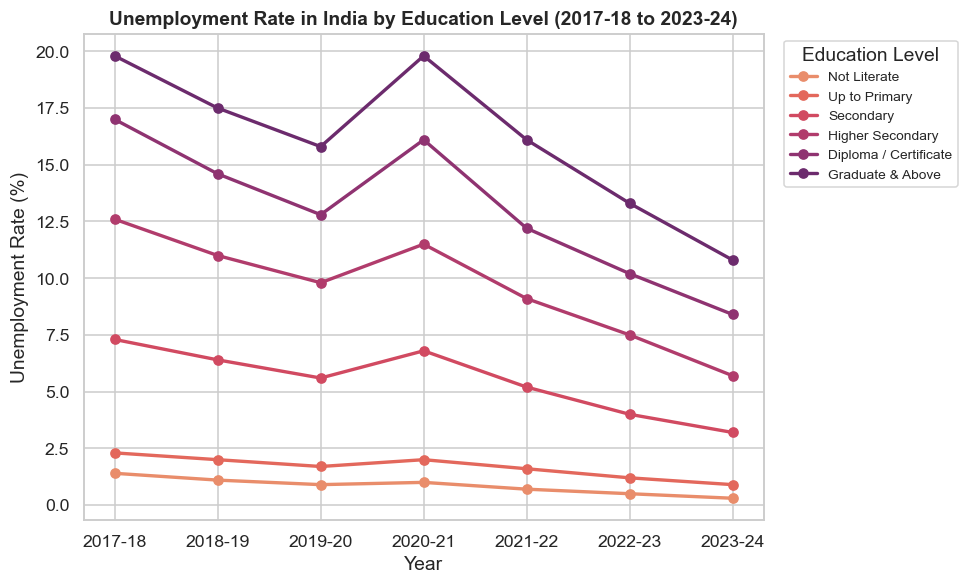

In [10]:
edu_order = ["Not Literate", "Up to Primary", "Secondary", "Higher Secondary", "Diploma / Certificate", "Graduate & Above"]
palette = sns.color_palette("flare", n_colors=len(edu_order))
total_df = df[(df.Region == "Total") & (df.Gender == "Person")]

plt.figure(figsize=(9, 5.5))
for color, edu in zip(palette, edu_order):
    sub = total_df[total_df.Education_Level == edu].sort_values("Year")
    plt.plot(sub.Year, sub.Unemployment_Rate_Percent, marker="o", label=edu, color=color, linewidth=2.2)
plt.title("Unemployment Rate in India by Education Level (2017-18 to 2023-24)", fontweight="bold")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Year")
plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


## 5. Latest Year Comparison (2023-24)

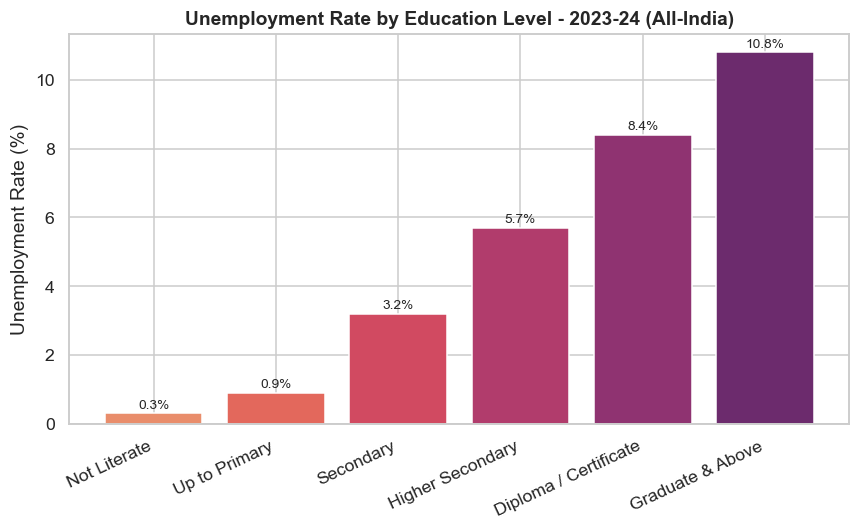

Graduate vs Not Literate ratio: 36.0 x


In [11]:
latest = total_df[total_df.Year == "2023-24"].set_index("Education_Level").loc[edu_order]

plt.figure(figsize=(8, 5))
bars = plt.bar(latest.index, latest.Unemployment_Rate_Percent, color=palette)
plt.title("Unemployment Rate by Education Level - 2023-24 (All-India)", fontweight="bold")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=25, ha="right")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.15, f"{h:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Graduate vs Not Literate ratio:", round(latest.loc["Graduate & Above", "Unemployment_Rate_Percent"] /
                                                 latest.loc["Not Literate", "Unemployment_Rate_Percent"], 1), "x")


## 6. Gender Gap by Education Level (2023-24)

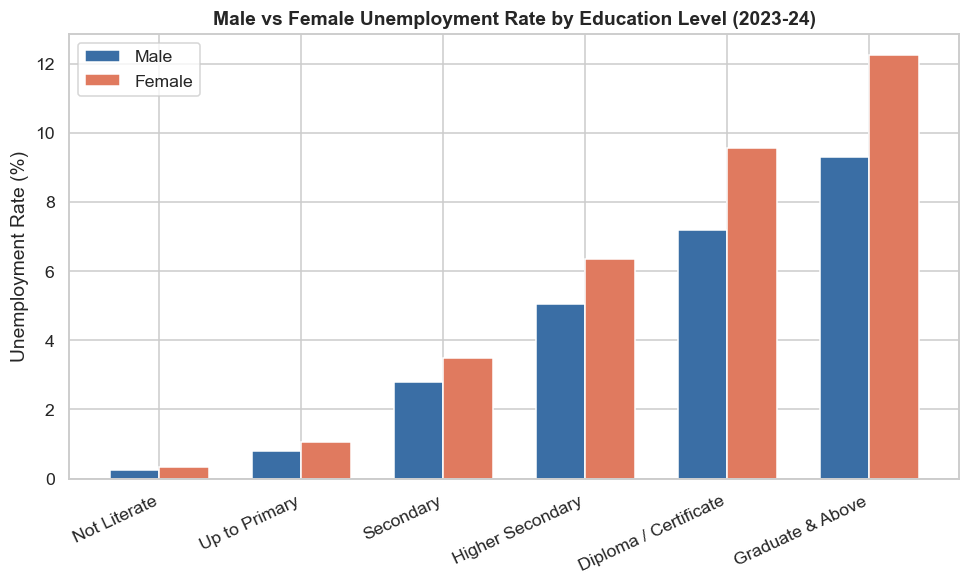

In [12]:
gender_latest = df[(df.Year == "2023-24") & (df.Gender.isin(["Male", "Female"])) & (df.Region.isin(["Rural", "Urban"]))]
gender_agg = gender_latest.groupby(["Education_Level", "Gender"])["Unemployment_Rate_Percent"].mean().reset_index()
gender_pivot = gender_agg.pivot(index="Education_Level", columns="Gender", values="Unemployment_Rate_Percent").loc[edu_order]

x = range(len(edu_order)); width = 0.35
plt.figure(figsize=(9, 5.5))
plt.bar([i - width/2 for i in x], gender_pivot["Male"], width=width, label="Male", color="#3A6EA5")
plt.bar([i + width/2 for i in x], gender_pivot["Female"], width=width, label="Female", color="#E07A5F")
plt.xticks(list(x), edu_order, rotation=25, ha="right")
plt.title("Male vs Female Unemployment Rate by Education Level (2023-24)", fontweight="bold")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Rural vs Urban Comparison (2023-24)

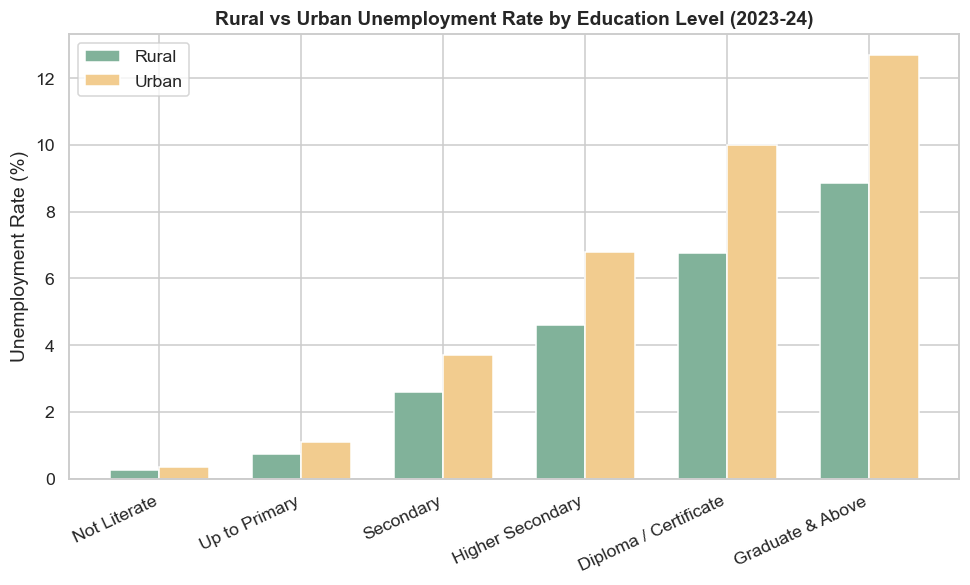

In [13]:
ru_latest = df[(df.Year == "2023-24") & (df.Gender.isin(["Male", "Female"])) & (df.Region.isin(["Rural", "Urban"]))]
ru_agg = ru_latest.groupby(["Education_Level", "Region"])["Unemployment_Rate_Percent"].mean().reset_index()
ru_pivot = ru_agg.pivot(index="Education_Level", columns="Region", values="Unemployment_Rate_Percent").loc[edu_order]

plt.figure(figsize=(9, 5.5))
plt.bar([i - width/2 for i in x], ru_pivot["Rural"], width=width, label="Rural", color="#81B29A")
plt.bar([i + width/2 for i in x], ru_pivot["Urban"], width=width, label="Urban", color="#F2CC8F")
plt.xticks(list(x), edu_order, rotation=25, ha="right")
plt.title("Rural vs Urban Unemployment Rate by Education Level (2023-24)", fontweight="bold")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Heatmap: Education Level × Year

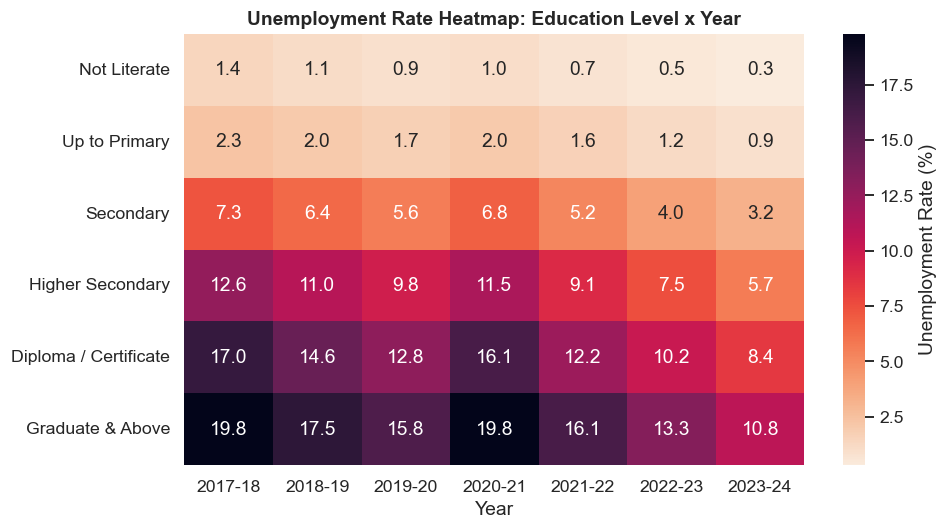

In [14]:
heat_df = total_df.pivot(index="Education_Level", columns="Year", values="Unemployment_Rate_Percent").loc[edu_order]

plt.figure(figsize=(9, 5))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="rocket_r", cbar_kws={"label": "Unemployment Rate (%)"})
plt.title("Unemployment Rate Heatmap: Education Level x Year", fontweight="bold")
plt.ylabel(""); plt.xlabel("Year")
plt.tight_layout()
plt.show()


## 9. Key Findings

- Unemployment rises sharply with education level: graduates face roughly **10x+ higher** unemployment than non-literate persons.
- A clear **COVID-19 spike** appears in 2020-21 across every education category, followed by steady recovery through 2023-24.
- **Female unemployment exceeds male unemployment** at every education level, with the gap widest among graduates.
- **Urban unemployment exceeds rural unemployment** at every education level, and the gap widens with higher education.

## 10. Conclusion

India's labour market shows a persistent "educated unemployment" paradox — formal-sector job creation has not kept pace with the growing number of educated job seekers, particularly affecting graduates, urban residents, and women. Policy responses could include industry-aligned skilling, urban/formal job creation, and targeted support for educated women's employment.
